In [1]:
from roctet import calc_roctet
from roctet.utils import auroc
from numpy import arange
import polars as pl
import polars.selectors as cs
import polars_ds as pds
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_abline,
    geom_density,
    facet_grid,
    labs,
    theme_set,
    theme_bw,
    theme,
)

In [2]:
theme_set(theme_bw())

## Data Generation

In [3]:
# generate datasets
dfs_beta = calc_roctet(0.82, method="beta", n_sets=10)  # 0.82, 0.67
dfs_pcws = calc_roctet(0.82, method="piecewise", n_sets=10)
dfs_beta[0].glimpse()

Rows: 100000
Columns: 3
$ score  <f64> 0.9996820338971453, 0.9990528738926949, 0.9992195794522248, 0.9991835553660647, 0.9991750809820671, 0.9998119064130688, 0.9999232682662933, 0.9992758502480452, 0.9998195741357288, 0.9998897824755868
$ target <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ index  <i32> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0



In [ ]:
# consolidate to one dataset
df = pl.concat(
    [d.with_columns(method=pl.lit("beta")) for d in dfs_beta] +
    [d.with_columns(method=pl.lit("piecewise")) for d in dfs_pcws]
)
df.glimpse()

## ROC Summary

In [30]:
# compare AUC values
aucs = [
    auroc(d["target"].to_numpy(), d["score"].to_numpy()) for d in dfs_beta + dfs_pcws
]
print(aucs)
print(f"Max Diff: {max(aucs) - min(aucs)}")

[0.8185, 0.8196, 0.8202, 0.8194, 0.8188, 0.819, 0.8192, 0.8171, 0.8176, 0.8193, 0.8202, 0.82, 0.8203, 0.8197, 0.8203, 0.8202, 0.8191, 0.819, 0.8192, 0.8195]
Max Diff: 0.0031999999999999806


## ROC Curves

C:\Users\emily\Desktop\roctet\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
C:\Users\emily\Desktop\roctet\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: aucs.png


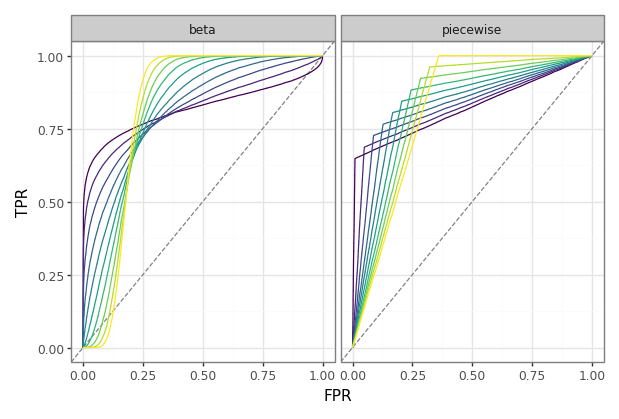

In [31]:
# compute and display roc curve
df_roc = (
    df.sort("score", descending=True)
    .with_columns(
        neg_target=1 - pl.col("target"),
        neg_target_ttl=(1 - pl.col("target")).sum().over("index", "method"),
        pos_target=pl.col("target"),
        pos_target_ttl=pl.col("target").sum().over("index", "method"),
    )
    .with_columns(
        cum_fpr=pl.col("neg_target").cum_sum().over("index", "method")
        / pl.col("neg_target_ttl"),
        cum_tpr=pl.col("pos_target").cum_sum().over("index", "method")
        / pl.col("pos_target_ttl"),
    )
)

p = ggplot(df_roc)
p += aes(x="cum_fpr", y="cum_tpr", color="index", group="index")
p += geom_abline(intercept=0, slope=1, color="grey", linetype="dashed")
p += geom_line()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p += labs(x="FPR", y="TPR")
p.save("aucs.png")
p

## Metrics

In [32]:
df_metrics = (
    df.group_by("method", "index")
    .agg(metrics=pds.query_binary_metrics("target", "score", 0.5))
    .unnest("metrics")
)
df_metrics

method,index,precision,recall,f,avg_precision,roc_auc
str,i32,f64,f64,f64,f64,f64
"""beta""",6,0.665086,0.993239,0.796695,0.708816,0.819244
"""piecewise""",2,0.631818,0.851468,0.72538,0.822968,0.820278
"""piecewise""",0,0.62483,0.82344,0.710517,0.870165,0.820187
"""beta""",7,0.664973,0.999158,0.79851,0.685993,0.817124
"""beta""",4,0.651853,0.939621,0.76972,0.783093,0.81876
…,…,…,…,…,…,…
"""piecewise""",1,0.628287,0.836851,0.717724,0.843852,0.819996
"""piecewise""",5,0.643171,0.902638,0.751129,0.776188,0.820194
"""piecewise""",8,0.659096,0.97184,0.785482,0.741529,0.819236


In [33]:
(
    df_metrics.drop("method", "index")
    .select(
        cs.all().std().name.prefix("std__"),
        (cs.all().max() - cs.all().min()).name.prefix("rng__"),
    )
    .unpivot()
    .with_columns(pl.col("variable").str.split_exact("__", 1))
    .unnest("variable")
    .pivot(index="field_1", on="field_0")
)

field_1,std,rng
str,f64,f64
"""precision""",0.015224,0.042037
"""recall""",0.064589,0.17656
"""f""",0.032581,0.089627
"""avg_precision""",0.064912,0.206228
"""roc_auc""",0.000861,0.003208


## Lift Charts

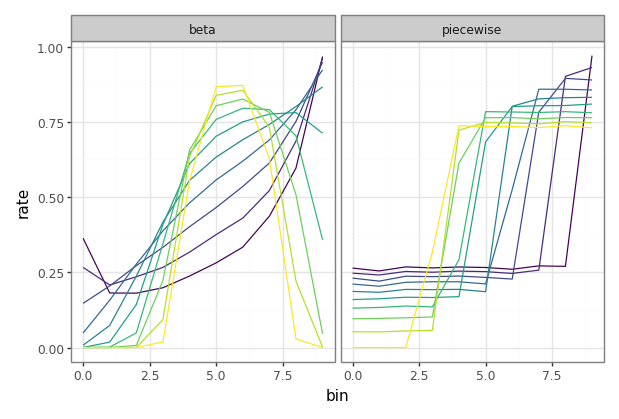

In [34]:
# visualize lift curves
df_lift = df.group_by(
    "method",
    "index",
    bin=pl.col("score")
    .qcut(10, labels=arange(10).astype(str))
    .cast(pl.String)
    .cast(pl.Int16),
).agg(rate=pl.col("target").mean())

p = ggplot(df_lift)
p += aes(x="bin", y="rate", color="index", group="index")
p += geom_line()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p

## Score Distribution

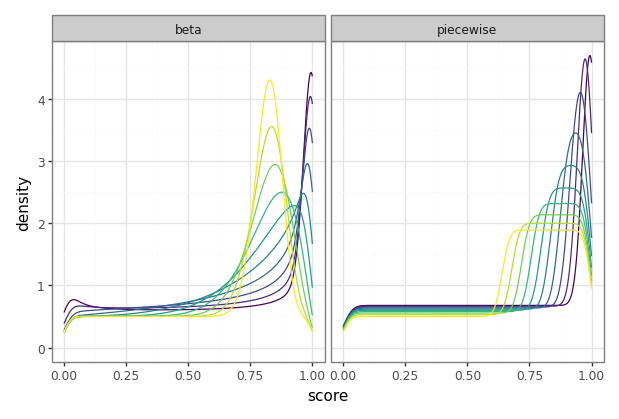

In [38]:
# visualize lift curves
df_lift = df.group_by(
    "method",
    "index",
    bin=pl.col("score")
    .qcut(10, labels=arange(10).astype(str))
    .cast(pl.String)
    .cast(pl.Int16),
).agg(rate=pl.col("target").mean())

p = ggplot(df)
p += aes(x="score", color="index", group="index")
p += geom_density()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p